# Diabetes Prediction using Neural Networks

This notebook demonstrates how to build and evaluate a neural network model to predict diabetes based on various health indicators. It includes steps for data loading, preprocessing, handling imbalanced data using SMOTE, model building with Keras, training, and evaluation.

In [1]:
from google.colab import files
uploaded=files.upload()

Saving diabetes (1).csv to diabetes (1).csv


## 1. Importing Libraries and Loading Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

### Loading Dataset

In [3]:
df=pd.read_csv('diabetes (1).csv')

## 2. Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Displaying the first 5 rows of the dataset

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Generating descriptive statistics of the dataset

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Checking skewness for specific columns

In [7]:
df['Glucose'].skew()

np.float64(0.17375350179188992)

In [8]:
df['BloodPressure'].skew()

np.float64(-1.8436079833551302)

In [9]:
df['Insulin'].skew()

np.float64(2.272250858431574)

In [10]:
df['SkinThickness'].skew()

np.float64(0.10937249648187608)

## 3. Data Cleaning: Handling Zero Values

In [11]:
df['Glucose']=df['Glucose'].replace({0:df['Glucose'].mean()})
df['BloodPressure']=df['BloodPressure'].replace({0:df['BloodPressure'].median()})
df['SkinThickness']=df['SkinThickness'].replace({0:df['SkinThickness'].median()})
df['Insulin']=df['Insulin'].replace({0:df['Insulin'].median()})
df['BMI']=df['BMI'].replace({0:df['BMI'].median()})

### Verifying changes after handling zero values

In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.681605,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.436016,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Checking the distribution of the target variable (`Outcome`)

In [13]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


## 4. Data Visualization

### Correlation Heatmap

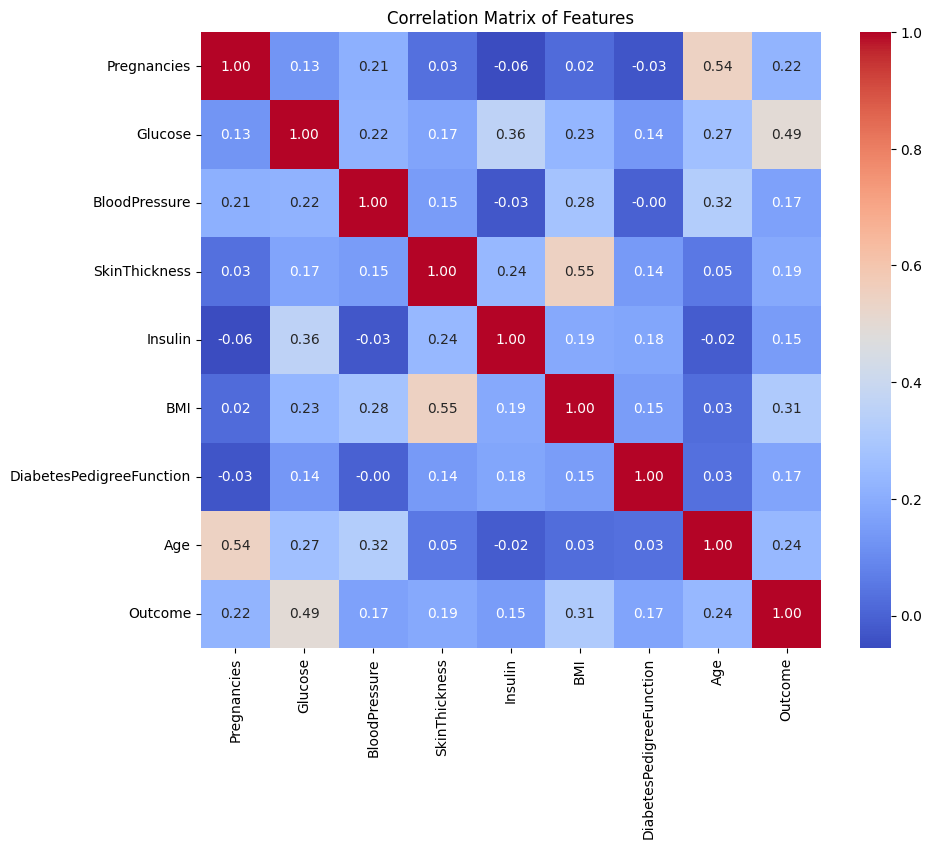

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

### Distribution of Key Features

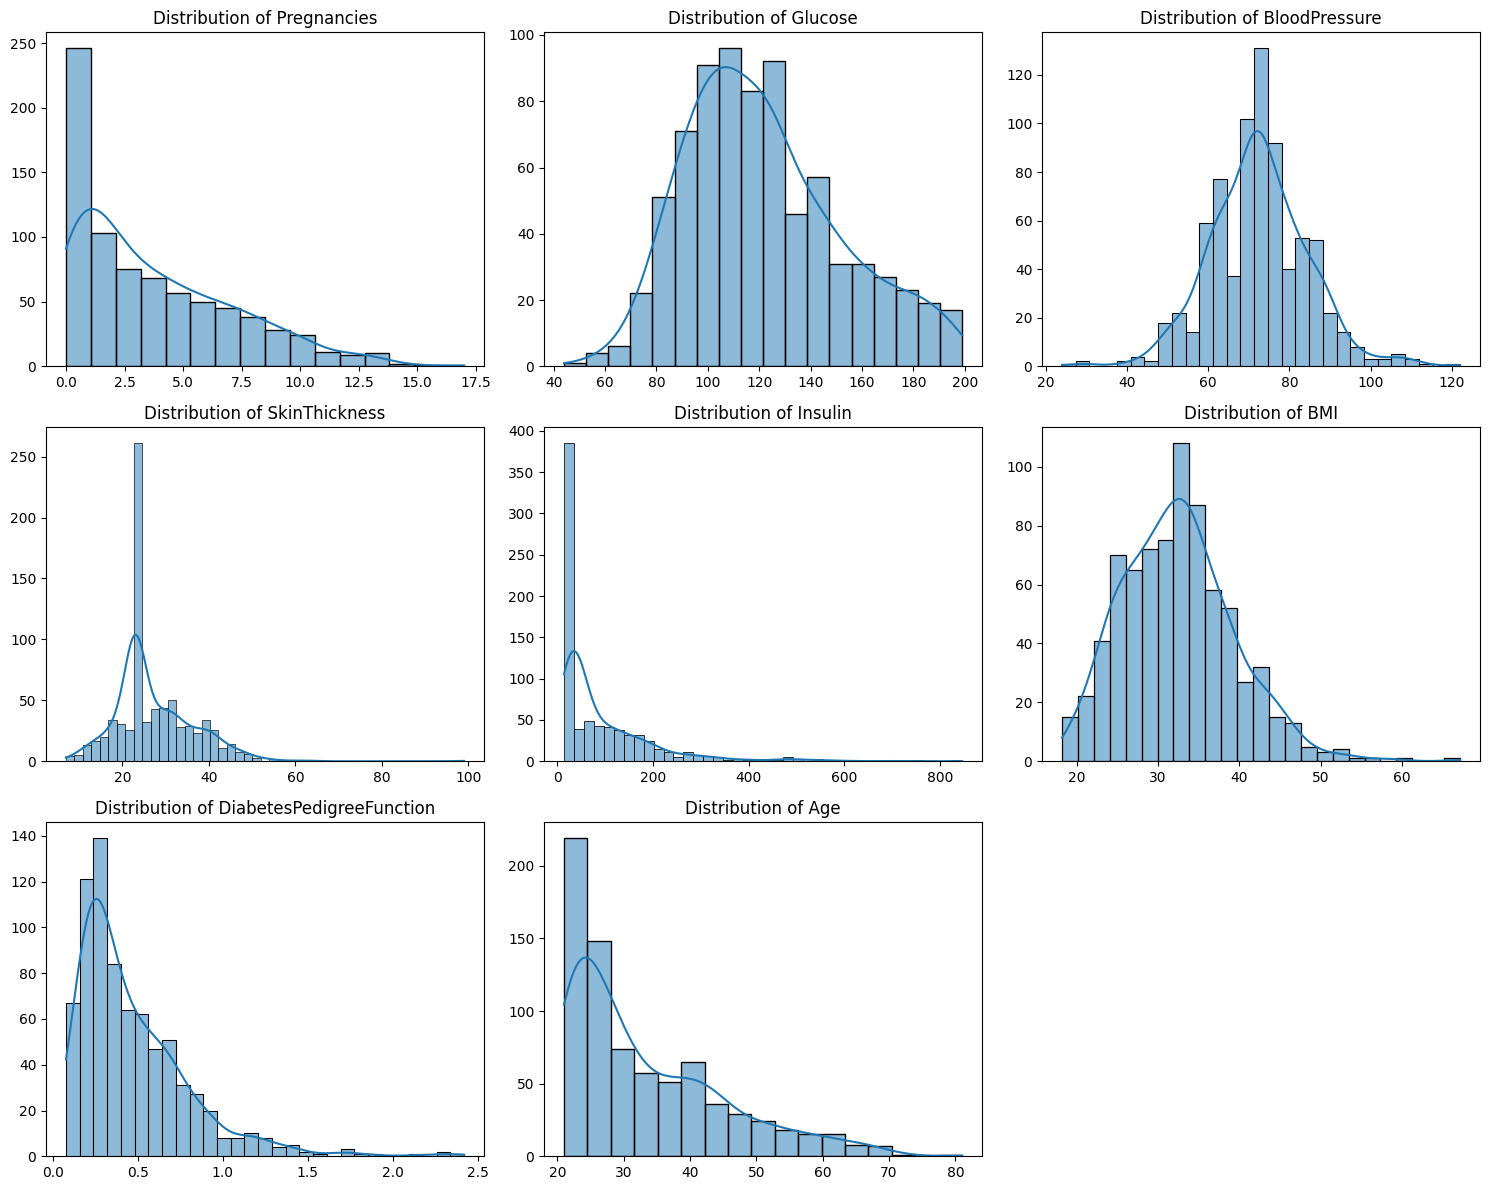

In [44]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Feature Distribution by Outcome

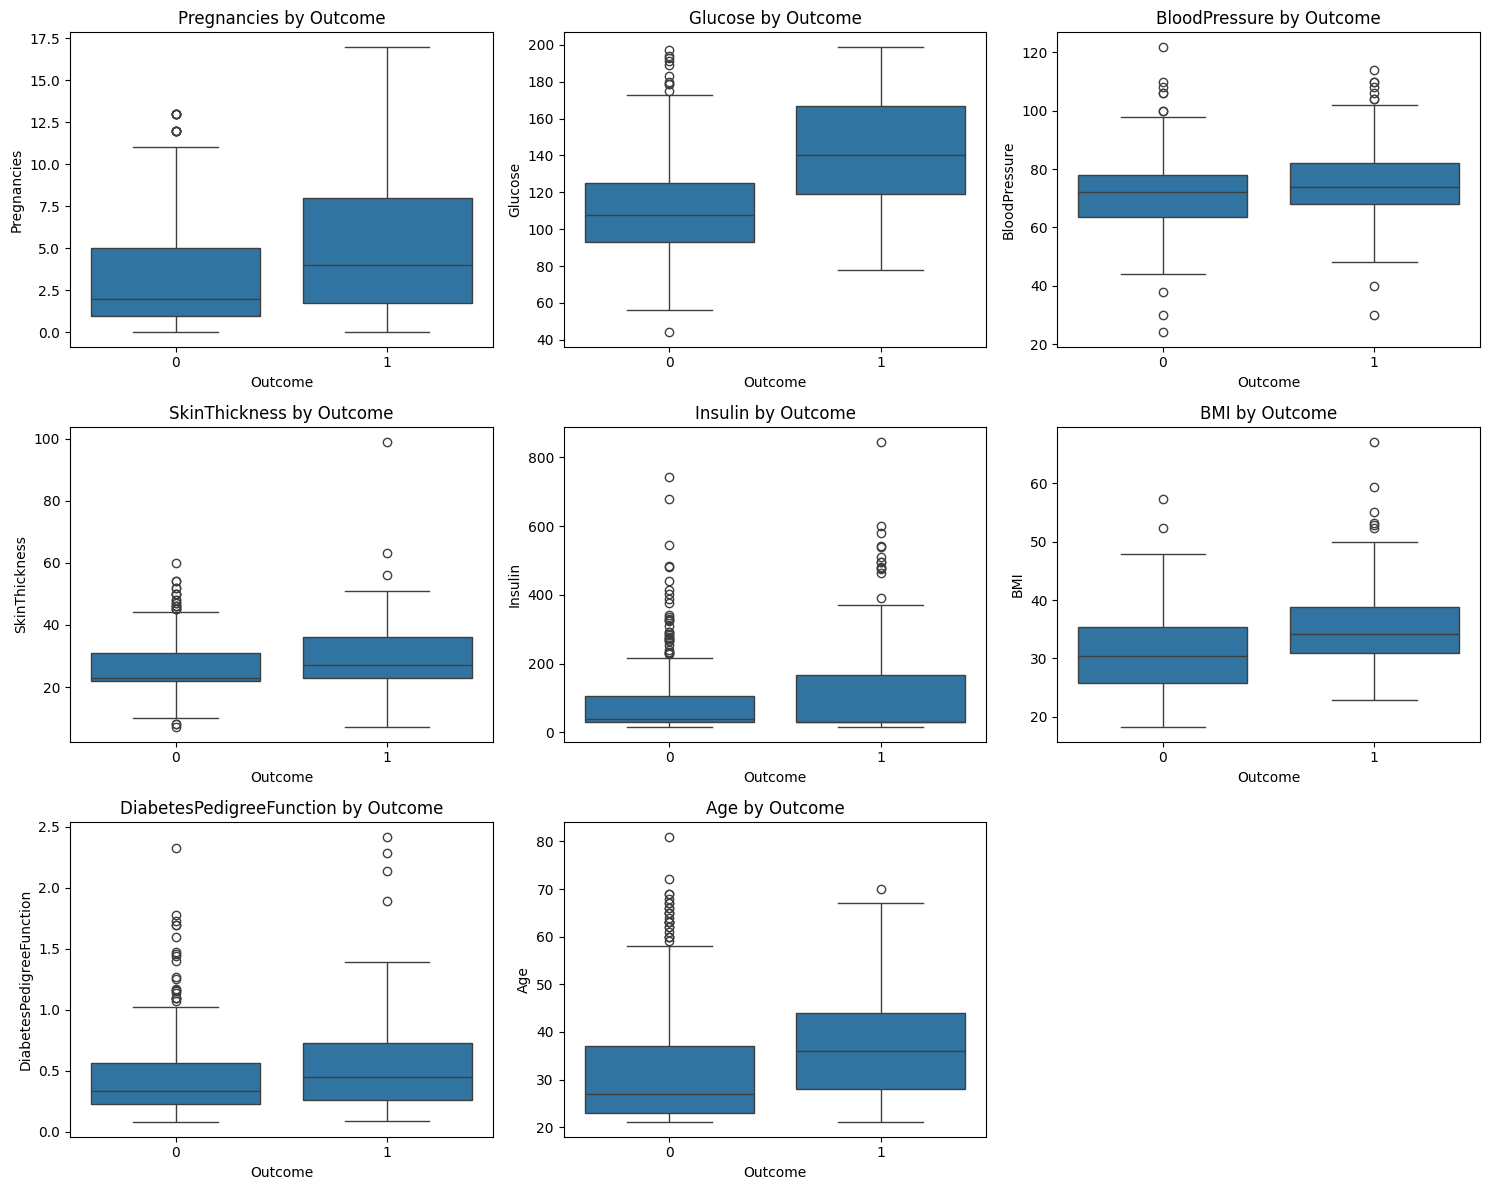

In [45]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='Outcome', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'{feature} by Outcome')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [14]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

### Splitting the data into training and testing sets

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)

### Scaling the features using StandardScaler

In [16]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## 5. Handling Imbalanced Data with SMOTE

In [17]:
!pip install imblearn

### Applying SMOTE to the training data

In [18]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

### Checking the distribution of the target variable after SMOTE

In [19]:
y_train_smote.value_counts()

,count
Outcome,
0,450
1,450


## 6. Building and Training the Neural Network (Without SMOTE)

In [20]:
model=Sequential()

### Defining the model architecture

In [21]:
model.add(Input(shape=(X_train_smote.shape[1],)))

In [22]:
model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

### Compiling the model

In [23]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

### Setting up Early Stopping callback

In [24]:
early_stop=EarlyStopping(monitor='val_accuracy',patience=10,restore_best_weights=True)

### Training the model

In [25]:
model.fit(X_train, y_train, epochs = 250, batch_size = 16, validation_split = 0.2, callbacks = [early_stop])

Epoch 1/250
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7156 - loss: 0.5412 - val_accuracy: 0.7626 - val_loss: 0.4633
Epoch 2/250
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7736 - loss: 0.4561 - val_accuracy: 0.7338 - val_loss: 0.4534
Epoch 3/250
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7826 - loss: 0.4340 - val_accuracy: 0.7122 - val_loss: 0.4533
Epoch 4/250
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8043 - loss: 0.4130 - val_accuracy: 0.7338 - val_loss: 0.4554
Epoch 5/250
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8043 - loss: 0.4066 - val_accuracy: 0.7410 - val_loss: 0.4861
Epoch 6/250
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8025 - loss: 0.3940 - val_accuracy: 0.7266 - val_loss: 0.4701
Epoch 7/250
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.3930 - val_accuracy: 0.7554 - val_loss: 0.4664
Epoch 8/250
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8297 - loss: 0.3639 - val_accuracy: 0.7266 - 

## 7. Model Evaluation (Without SMOTE)

In [26]:
y_pred=model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


### Converting predictions to binary (0 or 1)

In [27]:
y_pred=(y_pred>0.5).astype(int)

### Importing `classification_report`

In [28]:
from sklearn.metrics import classification_report

### Printing the classification report

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.68      0.72        50
           1       0.52      0.63      0.57        27

    accuracy                           0.66        77
   macro avg       0.64      0.65      0.65        77
weighted avg       0.68      0.66      0.67        77



## 8. Building and Training the Neural Network (With SMOTE)

In [30]:
model_1=Sequential()

### Defining the model architecture (using SMOTE-enhanced data)

In [31]:
model_1.add(Input(shape=(X_train_smote.shape[1],)))

In [32]:
model_1.add(Dense(256,activation='relu'))
model_1.add(Dense(128,activation='relu'))
model_1.add(Dense(64,activation='relu'))
model_1.add(Dense(32,activation='relu'))
model_1.add(Dense(1,activation='sigmoid'))

### Compiling the model

In [33]:
model_1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

### Setting up Early Stopping callback (re-initializing for the new model)

In [34]:
early_stop=EarlyStopping(monitor='val_accuracy',patience=10,restore_best_weights=True)

### Training the model with SMOTE-resampled data

In [35]:
model_1.fit(X_train_smote, y_train_smote, epochs = 250, batch_size = 16, validation_split = 0.2, callbacks = [early_stop])

Epoch 1/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7347 - loss: 0.5161 - val_accuracy: 0.5500 - val_loss: 0.7628
Epoch 2/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7861 - loss: 0.4419 - val_accuracy: 0.6500 - val_loss: 0.6436
Epoch 3/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7833 - loss: 0.4303 - val_accuracy: 0.6333 - val_loss: 0.6037
Epoch 4/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7847 - loss: 0.4148 - val_accuracy: 0.7556 - val_loss: 0.4693
Epoch 5/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8000 - loss: 0.4074 - val_accuracy: 0.6444 - val_loss: 0.6218
Epoch 6/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8069 - loss: 0.3969 - val_accuracy: 0.8167 - val_loss: 0.4339
Epoch 7/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8069 - loss: 0.3805 - val_accuracy: 0.6889 - val_loss: 0.5567
Epoch 8/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8153 - loss: 0.3678 - val_accuracy: 0.7389 - 

## 9. Model Evaluation (With SMOTE)

In [50]:
y_pred=model_1.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


### Converting predictions to binary (0 or 1)

In [51]:
y_pred=(y_pred>0.5).astype(int)

### Importing `classification_report`

In [52]:
from sklearn.metrics import classification_report

### Printing the classification report

In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78        50
           1       0.60      0.56      0.58        27

    accuracy                           0.71        77
   macro avg       0.68      0.68      0.68        77
weighted avg       0.71      0.71      0.71        77



## 10. Summary and Comparison

This section compares the performance of the neural network models trained with and without SMOTE for handling class imbalance. The classification reports highlight the precision, recall, and f1-score for each class (0: Non-Diabetic, 1: Diabetic).

In [54]:
print('--- Classification Report (Without SMOTE) ---')
y_pred_no_smote = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred_no_smote))

print('\n--- Classification Report (With SMOTE) ---')
y_pred_smote = (model_1.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred_smote))

--- Classification Report (Without SMOTE) ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       0.77      0.68      0.72        50
           1       0.52      0.63      0.57        27

    accuracy                           0.66        77
   macro avg       0.64      0.65      0.65        77
weighted avg       0.68      0.66      0.67        77


--- Classification Report (With SMOTE) ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

           0       0.77      0.80      0.78        50
           1       0.60      0.56      0.58        27

    accuracy                           0.71        77
   macro avg       0.68      0.68      0.68        77
weighted avg       0.71      0.71      0.71        77



### Key Insights from Model Comparison:

*   **Without SMOTE:**
    *   The model achieved an accuracy of 0.66.
    *   Precision for class 1 (diabetic) was 0.52, and recall was 0.63, indicating that the model struggled to accurately identify positive cases and had a moderate rate of true positives among all actual positives.
    *   The f1-score for class 1 was 0.57.

*   **With SMOTE:**
    *   The model showed an improved accuracy of 0.71.
    *   Precision for class 1 (diabetic) was 0.60, and recall was 0.56. While precision improved, recall slightly decreased compared to the non-SMOTE model, which might suggest a trade-off.
    *   The f1-score for class 1 improved to 0.58.

**Overall Conclusion:**
Applying SMOTE helped to balance the dataset and generally improved the model's overall accuracy. For class 0 (non-diabetic), SMOTE led to higher recall (0.80 vs 0.68), meaning fewer non-diabetic cases were misclassified as diabetic. For class 1 (diabetic), while precision improved, there was a slight drop in recall. This indicates that while the model was better at ensuring predicted positives were actually positive, it might have missed a few actual positive cases. The `macro avg` and `weighted avg` f1-scores also improved, suggesting a more robust model after handling imbalance.

## 11. Precision-Recall Curve Comparison

A Precision-Recall curve illustrates the trade-off between precision and recall for different threshold settings. It is particularly useful for imbalanced datasets, as it provides a more informative picture than the ROC curve when the positive class is rare.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


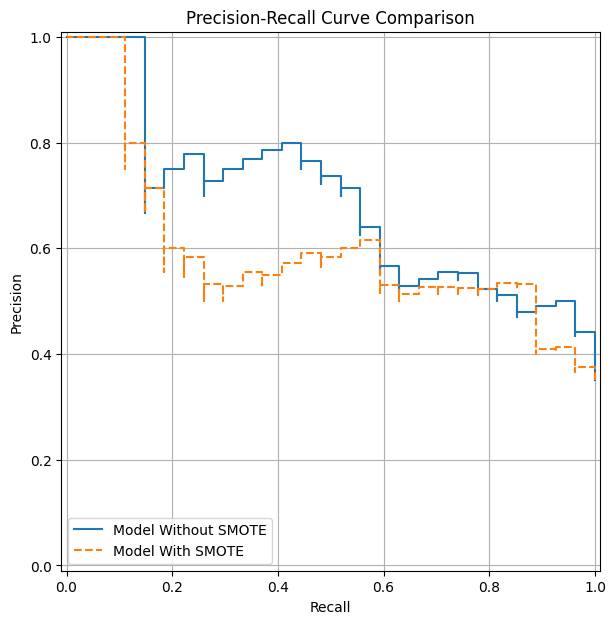

In [55]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

plt.figure(figsize=(10, 7))

# --- Model without SMOTE ---
# Get predicted probabilities for the positive class
y_pred_prob_no_smote = model.predict(X_test)

# Compute precision-recall pairs
precision_no_smote, recall_no_smote, _ = precision_recall_curve(y_test, y_pred_prob_no_smote)

# Plot the precision-recall curve
display_no_smote = PrecisionRecallDisplay(precision=precision_no_smote, recall=recall_no_smote, estimator_name='Without SMOTE')
display_no_smote.plot(ax=plt.gca(), name='Model Without SMOTE')

# --- Model with SMOTE ---
# Get predicted probabilities for the positive class
y_pred_prob_smote = model_1.predict(X_test)

# Compute precision-recall pairs
precision_smote, recall_smote, _ = precision_recall_curve(y_test, y_pred_prob_smote)

# Plot the precision-recall curve
display_smote = PrecisionRecallDisplay(precision=precision_smote, recall=recall_smote, estimator_name='With SMOTE')
display_smote.plot(ax=plt.gca(), name='Model With SMOTE', linestyle='--')

plt.title('Precision-Recall Curve Comparison')
plt.grid(True)
plt.show()

### Interpretation of Precision-Recall Curves:

*   **Higher Curve, Better Performance:** A curve that is closer to the top-right corner indicates better performance, as it implies higher precision and recall simultaneously.
*   **Area Under the Curve (AUC-PR):** While not explicitly calculated here, a larger area under the precision-recall curve (AUC-PR) suggests a better model, especially for imbalanced datasets.

By comparing these curves, we can visually assess which model maintains a better balance between precision and recall across various thresholds, offering further insight into the impact of SMOTE on the model's ability to identify diabetic cases while minimizing false positives.

## 12. ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The Area Under the Curve (AUC-ROC) summarizes the overall performance of the classifier.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


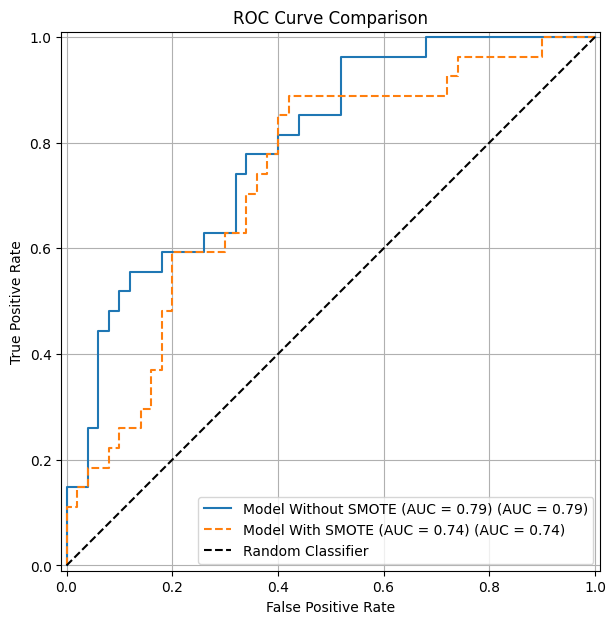

In [56]:
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score

plt.figure(figsize=(10, 7))

# --- Model without SMOTE ---
# Get predicted probabilities for the positive class
y_pred_prob_no_smote = model.predict(X_test).ravel()

# Compute ROC curve
fpr_no_smote, tpr_no_smote, _ = roc_curve(y_test, y_pred_prob_no_smote)
auc_roc_no_smote = roc_auc_score(y_test, y_pred_prob_no_smote)

# Plot the ROC curve
display_no_smote = RocCurveDisplay(fpr=fpr_no_smote, tpr=tpr_no_smote, roc_auc=auc_roc_no_smote, estimator_name='Without SMOTE')
display_no_smote.plot(ax=plt.gca(), name=f'Model Without SMOTE (AUC = {auc_roc_no_smote:.2f})')

# --- Model with SMOTE ---
# Get predicted probabilities for the positive class
y_pred_prob_smote = model_1.predict(X_test).ravel()

# Compute ROC curve
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_pred_prob_smote)
auc_roc_smote = roc_auc_score(y_test, y_pred_prob_smote)

# Plot the ROC curve
display_smote = RocCurveDisplay(fpr=fpr_smote, tpr=tpr_smote, roc_auc=auc_roc_smote, estimator_name='With SMOTE')
display_smote.plot(ax=plt.gca(), name=f'Model With SMOTE (AUC = {auc_roc_smote:.2f})', linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Baseline random classifier
plt.title('ROC Curve Comparison')
plt.grid(True)
plt.legend()
plt.show()

### Interpretation of ROC Curves:

*   **Curve Position:** A ROC curve that bows more towards the top-left corner indicates a better model, as it achieves a higher True Positive Rate (TPR) for a given False Positive Rate (FPR).
*   **Area Under the Curve (AUC-ROC):** The AUC-ROC value provides a single metric to summarize the model's performance across all possible classification thresholds. A higher AUC-ROC (closer to 1.0) signifies a better ability to distinguish between positive and negative classes. An AUC of 0.5 suggests a model performs no better than random chance.

By comparing the AUC values and the shape of the ROC curves for both models, we can gain further insight into their overall discriminatory power, considering both true positives and false positives.